# Modeling
## Predicting Customer Lifetime Value to Optimize Value-Based Bidding and Paid Advertising Budget Allocation

**Student:** Christian Alan Vibar\
**Course:** MAB2134 Analytics Algorithms 1 (Predictive Analytics 1)  
**Term:** 3rd / SY 2025–2026  
**Instructor:** Francis Adrian Viernes, CFA, MBA, MSF, CCREP, PMDSA

---

### Purpose of this Notebook
This notebook covers the Modeling and Evaluation phases of CRISP-DM. It loads the analytical dataset produced by `02_preprocessing.ipynb` and implements four model families in sequence: dummy baseline, Ridge regression, decision tree, and random forest. All models are evaluated on the same validation design: 5-fold cross-validation on the training set for hyperparameter selection, followed by a single final evaluation on the held-out test set. The test set is touched exactly once per model, after hyperparameter selection is complete.

---

### Modeling Decisions Summary

| Decision | Choice | Justification |
|---|---|---|
| Validation strategy | 5-fold cross-validation | n=427 training rows; single split too unstable; ~85 rows per fold sufficient for stable MAE estimate |
| Tuning approach | `RandomizedSearchCV` (Ridge, tree models) | Efficient search over hyperparameter space; fixed `random_state` for reproducibility |
| Primary metric | MAE (USD) | Symmetric; interpretable as average dollar error per customer; matched to business cost |
| Secondary metric | RMSE (USD) | Penalizes large errors; complements MAE for right-skewed target |
| Target variants | Raw + `log1p`-transformed | Linear models expected to benefit from log transform; tree models less sensitive |
| kNN | Excluded | Sparse binary OHE geometry (80.7%) degrades distance calculations |

## 0. Preliminaries

In [1]:
# BASIC PACKAGES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# SKLEARN — MODEL FAMILIES
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# SKLEARN — VALIDATION & TUNING
from sklearn.model_selection import cross_val_score, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error

# REPRODUCIBILITY
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# CV SETTINGS
CV_FOLDS = 5
SCORING = 'neg_mean_absolute_error'

# DISPLAY
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_style('whitegrid')
plt.style.use('seaborn-v0_8-whitegrid')

# ── Helper: print a clean score summary row ──────────────────────────────────
def report_scores(model_name, cv_mae, test_mae, test_rmse, note=''):
    print(f"{'Model':<30} {'CV MAE':>12} {'Test MAE':>12} {'Test RMSE':>12}")
    print('-' * 70)
    print(f"{model_name:<30} ${cv_mae:>10,.0f} ${test_mae:>10,.0f} ${test_rmse:>10,.0f}  {note}")

# ── Helper: compute CV MAE from cross_val_score ──────────────────────────────
def cv_mae(estimator, X, y):
    scores = cross_val_score(estimator, X, y,
                             cv=CV_FOLDS,
                             scoring=SCORING,
                             n_jobs=-1)
    return -scores.mean(), scores.std()

# ── Helper: Compute RMSE ────────────────────────────── 
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

print('Packages loaded.')

Packages loaded.


## 1. Load Processed Data

All datasets were produced by `02_preprocessing.ipynb` and saved to `../data/processed/`. Two versions exist:
- **Unscaled** (`X_train.csv`, `X_test.csv`): for tree-based models
- **Scaled** (`X_train_scaled.csv`, `X_test_scaled.csv`): for Ridge regression

In [2]:
# Unscaled — tree models
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')

# Scaled — Ridge regression
X_train_scaled = pd.read_csv('../data/processed/X_train_scaled.csv')
X_test_scaled  = pd.read_csv('../data/processed/X_test_scaled.csv')

# Targets
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

print('Shapes:')
print(f'  X_train:        {X_train.shape}')
print(f'  X_test:         {X_test.shape}')
print(f'  X_train_scaled: {X_train_scaled.shape}')
print(f'  X_test_scaled:  {X_test_scaled.shape}')
print(f'  y_train:        {y_train.shape}')
print(f'  y_test:         {y_test.shape}')

# Sanity checks
assert X_train.shape[0] == y_train.shape[0], 'Train size mismatch'
assert X_test.shape[0]  == y_test.shape[0],  'Test size mismatch'
assert X_train.isnull().sum().sum() == 0,     'Nulls in X_train'
assert X_test.isnull().sum().sum()  == 0,     'Nulls in X_test'
print('\nAll sanity checks passed.')

Shapes:
  X_train:        (427, 31)
  X_test:         (107, 31)
  X_train_scaled: (427, 31)
  X_test_scaled:  (107, 31)
  y_train:        (427,)
  y_test:         (107,)

All sanity checks passed.


In [3]:
# Log-transformed target variants
y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)

print(f'y_train — mean: ${y_train.mean():,.0f}  median: ${y_train.median():,.0f}  max: ${y_train.max():,.0f}')
print(f'y_test  — mean: ${y_test.mean():,.0f}  median: ${y_test.median():,.0f}  max: ${y_test.max():,.0f}')

y_train — mean: $24,158  median: $17,040  max: $214,365
y_test  — mean: $21,262  median: $19,213  max: $95,317


## 2. Baseline Models

Per the target-shape-to-baseline mapping (mean vs. median vs. naive rule, by target shape), the **median** baseline is used as the performance floor. `revenue_first_12_months` is right-skewed with outliers (confirmed in EDA Section 4.2 and reconfirmed by the MAE/RMSE divergence on both dummies), and the median is the more robust naive predictor for skewed targets with extreme values.

In [4]:
# ── Median baseline ──────────────────────────────────────────────────────────
dummy_median = DummyRegressor(strategy='median')
dummy_median.fit(X_train, y_train)

dummy_median_cv, dummy_median_cv_std = cv_mae(dummy_median, X_train, y_train)
dummy_median_pred = dummy_median.predict(X_test)
dummy_median_test_mae  = mean_absolute_error(y_test, dummy_median_pred)
dummy_median_test_rmse = rmse(y_test, dummy_median_pred)

print('Median Baseline:')
report_scores('Dummy (median)', dummy_median_cv, dummy_median_test_mae, dummy_median_test_rmse)
print(f'  Predicted value for every customer: ${float(dummy_median.constant_[0]):,.0f}')

Median Baseline:
Model                                CV MAE     Test MAE    Test RMSE
----------------------------------------------------------------------
Dummy (median)                 $    13,336 $     9,898 $    14,286  
  Predicted value for every customer: $17,040


In [5]:
# ── Baseline summary ─────────────────────────────────────────────────────────
print('\n--- Baseline Performance Summary ---')
print(f"{'Model':<25} {'CV MAE':>12} {'Test MAE':>12} {'Test RMSE':>12}")
print('-' * 65)
print(f"{'Dummy (median)':<25} ${dummy_median_cv:>10,.0f} ${dummy_median_test_mae:>10,.0f} ${dummy_median_test_rmse:>10,.0f}")
print()
print(f'Performance bar: any candidate model must achieve Test MAE < ${dummy_median_test_mae:,.0f}')
print(f'to justify the additional complexity over a naive median prediction.')


--- Baseline Performance Summary ---
Model                           CV MAE     Test MAE    Test RMSE
-----------------------------------------------------------------
Dummy (median)            $    13,336 $     9,898 $    14,286

Performance bar: any candidate model must achieve Test MAE < $9,898
to justify the additional complexity over a naive median prediction.


**Observations**: The median baseline assigns every customer `$17,040` (the training median), producing a Test MAE of `$9,898` and Test RMSE of `$14,286`. Any candidate model must achieve Test MAE < `$9,898` to demonstrate that feature-based learning adds value over a naive rule. A model that cannot beat this bar cannot differentiate between a `$5,000` CLV customer and a `$50,000` CLV customer, making it useless for VBB bid differentiation.

## 3. Ridge Regression

Ridge regression is the interpretable linear baseline. It serves two purposes: (1) testing whether a linear relationship between features and CLV is sufficient, and (2) providing an interpretability benchmark through signed coefficients.

### Why Ridge over OLS?
With 31 OHE features and n=427, ordinary least squares is at risk of overfitting, particularly given the high sparsity (80.7%) and the dominant signal from `starting_mrr`. Ridge adds an L2 penalty that shrinks coefficients toward zero, improving generalization without eliminating any feature entirely.

### Tuning strategy
The penalty strength alpha is selected by 5-fold CV on the training set using negative MAE as the scoring metric. `neg_mean_absolute_error` is used because scikit-learn's search tools are built to maximize the scoring metric, and since lower MAE is better, the sign is flipped so that maximizing the score is equivalent to minimizing MAE, with the sign reversed back when reporting results. This is consistent with the slide guidance: "Tune λ by cross-validation on the metric that matters. Choose on training/validation only, then refit once on the full training data." The test set is not consulted until the final evaluation.

In [6]:
# ── Hyperparameter search ────────────────────────────────────────────────────
from scipy.stats import loguniform

ridge_param_dist = {
    'alpha': loguniform(1e-2, 1e4)  # log-uniform search over [0.01, 10000]
}

ridge_search = RandomizedSearchCV(
    Ridge(),
    param_distributions=ridge_param_dist,
    n_iter=50,
    scoring=SCORING, # 'neg_mean_absolute_error'
    cv=CV_FOLDS,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    refit=True  # refit on full training data with best alpha
)

ridge_search.fit(X_train_scaled, y_train)

best_alpha = ridge_search.best_params_['alpha']
best_cv_mae = -ridge_search.best_score_

print(f'Best alpha: {best_alpha:.4f}')
print(f'Best CV MAE: ${best_cv_mae:,.0f}')

Best alpha: 19.0661
Best CV MAE: $9,019


In [7]:
# ── Evaluate on test set ─────────────────────────────────────────────────────
ridge_best = ridge_search.best_estimator_

ridge_pred = ridge_best.predict(X_test_scaled)
ridge_test_mae  = mean_absolute_error(y_test, ridge_pred)
ridge_test_rmse = rmse(y_test, ridge_pred)

print('Ridge Regression (raw target):')
report_scores('Ridge (raw)', best_cv_mae, ridge_test_mae, ridge_test_rmse,
              note=f'alpha={best_alpha:.3f}')

Ridge Regression (raw target):
Model                                CV MAE     Test MAE    Test RMSE
----------------------------------------------------------------------
Ridge (raw)                    $     9,019 $     7,624 $    10,984  alpha=19.066


In [8]:
# ── Log-transformed variant ──────────────────────────────────────────────────
ridge_log_search = RandomizedSearchCV(
    Ridge(),
    param_distributions=ridge_param_dist,
    n_iter=50,
    scoring=SCORING,
    cv=CV_FOLDS,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    refit=True
)
ridge_log_search.fit(X_train_scaled, y_train_log)

best_alpha_log = ridge_log_search.best_params_['alpha']
ridge_log_pred_log = ridge_log_search.best_estimator_.predict(X_test_scaled)
ridge_log_pred = np.expm1(ridge_log_pred_log)  # back-transform to USD

ridge_log_test_mae  = mean_absolute_error(y_test, ridge_log_pred)
ridge_log_test_rmse = rmse(y_test, ridge_log_pred)
ridge_log_cv_mae    = -ridge_log_search.best_score_  # note: CV score is in log space

print('Ridge Regression (log1p target):')
print(f'  Best alpha: {best_alpha_log:.4f}')
print(f'  Test MAE (back-transformed): ${ridge_log_test_mae:,.0f}')
print(f'  Test RMSE (back-transformed): ${ridge_log_test_rmse:,.0f}')

Ridge Regression (log1p target):
  Best alpha: 19.0661
  Test MAE (back-transformed): $8,464
  Test RMSE (back-transformed): $14,634


Top 15 coefficients by absolute magnitude:
                           feature  coefficient
                      starting_mrr     16802.07
             cb_sector_Health Care      3545.10
                       lifecycle_2     -2794.25
            service_offering_sales      2761.23
             cb_sector_Industrials      2581.02
               campaign_group_pmax      2502.66
 cb_annual_revenue_ranges_$1M-$10M      2120.69
         cb_employees_range_51-250      2070.14
  campaign_group_no_campaign_group     -1966.72
service_offering_virtual_assistant     -1919.95
              cb_sector_Financials      1811.60
            service_offering_other     -1704.82
                       lifecycle_3     -1161.11
        campaign_group_core_search     -1040.06
                  ad_network_other     -1008.77


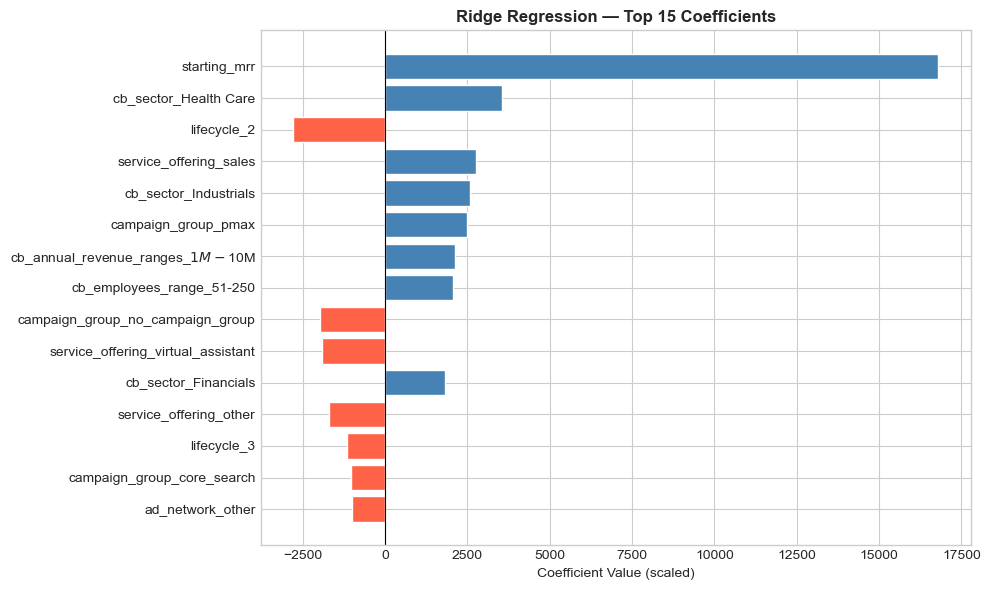

In [9]:
# ── Top coefficients ─────────────────────────────────────────────────────────
feature_names = X_train_scaled.columns.tolist()
coef = ridge_best.coef_

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coef
}).sort_values('coefficient', key=abs, ascending=False).head(15)

print('Top 15 coefficients by absolute magnitude:')
print(coef_df.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['steelblue' if c > 0 else 'tomato' for c in coef_df['coefficient']]
ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Ridge Regression — Top 15 Coefficients', fontweight='bold')
ax.set_xlabel('Coefficient Value (scaled)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**Observations**: Ridge regression (alpha=19.07, raw target) achieves Test MAE of `$7,624`, beating the median dummy (`$9,898`) and confirming that the feature set carries real predictive signal. The CV MAE (`$9,019`) is higher than the test MAE (`$7,624`), suggesting no overfitting. The log1p variant performed worse (Test MAE `$8,464`, RMSE `$14,634`), indicating that the back-transformation amplified errors in the right tail more than the log compression helped. Therefore, **the raw target variant is retained.**

The coefficient table confirms the EDA signal rankings. `starting_mrr` dominates by a wide margin (coefficient: +`$16,802` per standard deviation), consistent with the Spearman ρ=0.856 finding. `cb_sector_Health Care` emerges as the second strongest positive predictor (+`$3,545`), a finding not prominent in the EDA that warrants business attention. Service offering coefficients are directionally consistent with the EDA: `service_offering_sales` is positive (+`$2,761`) and `service_offering_virtual_assistant` is negative (-`$1,920`) relative to the reference category. `lifecycle_2` carries a negative coefficient (-`$2,794`), consistent with the counter-intuitive lifecycle direction identified in the EDA. The MAE-RMSE gap (`$7,624` vs `$10,984`) indicates Ridge is making some large errors on high-value customers in the right tail. This is a known limitation of linear models on skewed targets.

## 4. Decision Tree

The decision tree is the interpretable nonlinear baseline. It can capture the non-monotonic feature-target relationships identified in the EDA (mid-market sweet spot in firmographic features, counter-intuitive lifecycle signal) without requiring manual feature engineering.

### Tuning strategy
`max_depth` is the primary hyperparameter, which controls the bias-variance tradeoff directly. A shallow tree underfits; a deep tree memorizes training data. `min_samples_leaf` sets a floor on how small a leaf node can be, which prevents the model from fitting individual outliers. Both are selected by 5-fold CV on the training set.

In [10]:
# ── Hyperparameter search ────────────────────────────────────────────────────
dt_param_dist = {
    'max_depth': [2, 3, 4, 5, 6, 8, 10, None],
    'min_samples_leaf': [5, 10, 15, 20, 30],
    'min_samples_split': [10, 20, 30, 50]
}

dt_search = RandomizedSearchCV(
    DecisionTreeRegressor(random_state=RANDOM_SEED),
    param_distributions=dt_param_dist,
    n_iter=40,
    scoring=SCORING,
    cv=CV_FOLDS,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    refit=True
)

dt_search.fit(X_train, y_train)

best_dt_params = dt_search.best_params_
best_dt_cv_mae = -dt_search.best_score_

print(f'Best params: {best_dt_params}')
print(f'Best CV MAE: ${best_dt_cv_mae:,.0f}')

Best params: {'min_samples_split': 30, 'min_samples_leaf': 30, 'max_depth': 6}
Best CV MAE: $7,969


In [11]:
# ── Evaluate on test set ─────────────────────────────────────────────────────
dt_best = dt_search.best_estimator_

dt_pred = dt_best.predict(X_test)
dt_test_mae  = mean_absolute_error(y_test, dt_pred)
dt_test_rmse = rmse(y_test, dt_pred)

print('Decision Tree:')
report_scores('Decision Tree (raw)', best_dt_cv_mae, dt_test_mae, dt_test_rmse,
              note=str(best_dt_params))

Decision Tree:
Model                                CV MAE     Test MAE    Test RMSE
----------------------------------------------------------------------
Decision Tree (raw)            $     7,969 $     5,788 $     8,546  {'min_samples_split': 30, 'min_samples_leaf': 30, 'max_depth': 6}


In [12]:
# ── Log-transformed variant ──────────────────────────────────────────────────
dt_log_search = RandomizedSearchCV(
    DecisionTreeRegressor(random_state=RANDOM_SEED),
    param_distributions=dt_param_dist,
    n_iter=40,
    scoring=SCORING,
    cv=CV_FOLDS,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    refit=True
)
dt_log_search.fit(X_train, y_train_log)

dt_log_pred = np.expm1(dt_log_search.best_estimator_.predict(X_test))
dt_log_test_mae  = mean_absolute_error(y_test, dt_log_pred)
dt_log_test_rmse = rmse(y_test, dt_log_pred)

print(f'Decision Tree (log1p) — Test MAE: ${dt_log_test_mae:,.0f}  RMSE: ${dt_log_test_rmse:,.0f}')

Decision Tree (log1p) — Test MAE: $5,369  RMSE: $8,290


Top 15 features by importance:
                             feature  importance
                        starting_mrr        1.00
  service_offering_virtual_assistant        0.00
          cb_employees_range_missing        0.00
                         lifecycle_5        0.00
service_offering_executive_assistant        0.00
              service_offering_other        0.00
                         lifecycle_2        0.00
              service_offering_sales        0.00
          campaign_group_core_search        0.00
    campaign_group_no_campaign_group        0.00
                 campaign_group_pmax        0.00
              campaign_group_scaling        0.00
                     ad_network_bing        0.00
                 ad_network_facebook        0.00
                         lifecycle_3        0.00


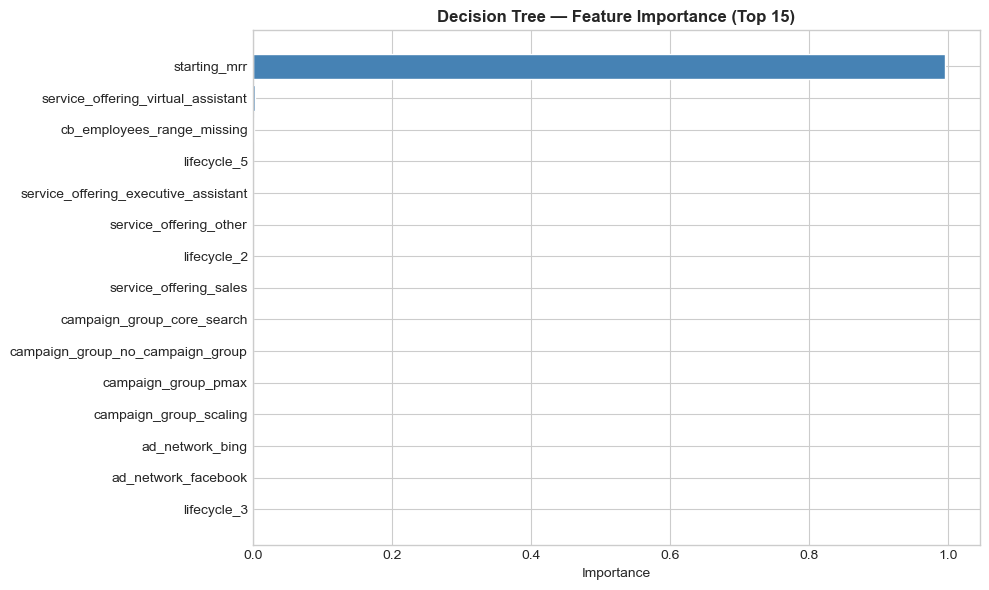

In [13]:
# ── Feature importance ───────────────────────────────────────────────────────
feat_imp = pd.DataFrame({
    'feature': X_train.columns,
    'importance': dt_best.feature_importances_
}).sort_values('importance', ascending=False).head(15)

print('Top 15 features by importance:')
print(feat_imp.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feat_imp['feature'], feat_imp['importance'], color='steelblue')
ax.set_title('Decision Tree — Feature Importance (Top 15)', fontweight='bold')
ax.set_xlabel('Importance')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

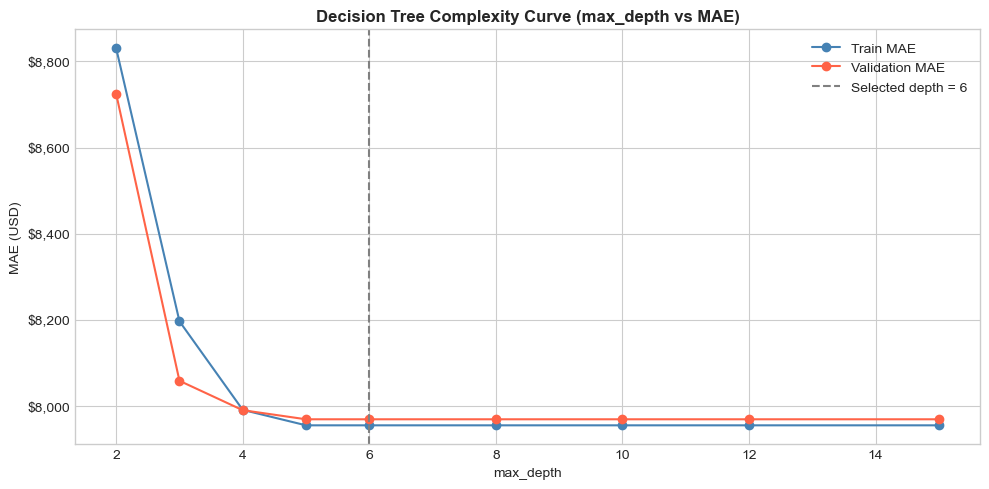

In [26]:
# ── Complexity curve — depth vs MAE ─────────────────────────────────────────────
from sklearn.model_selection import validation_curve

depth_range = [2, 3, 4, 5, 6, 8, 10, 12, 15]

train_scores, val_scores = validation_curve(
    DecisionTreeRegressor(
        min_samples_leaf=best_dt_params['min_samples_leaf'],
        min_samples_split=best_dt_params['min_samples_split'],
        random_state=RANDOM_SEED
    ),
    X_train, y_train,
    param_name='max_depth',
    param_range=depth_range,
    cv=CV_FOLDS,
    scoring=SCORING,
    n_jobs=-1
)

train_mae = -train_scores.mean(axis=1)
val_mae   = -val_scores.mean(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(depth_range, train_mae, 'o-', label='Train MAE', color='steelblue')
ax.plot(depth_range, val_mae,   'o-', label='Validation MAE',    color='tomato')
ax.axvline(best_dt_params['max_depth'], color='gray', linestyle='--',
           label=f"Selected depth = {best_dt_params['max_depth']}")
ax.set_title('Decision Tree Complexity Curve (max_depth vs MAE)', fontweight='bold')
ax.set_xlabel('max_depth')
ax.set_ylabel('MAE (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()
plt.tight_layout()

**Observations**: The decision tree (max_depth=6, min_samples_leaf=30, raw target) achieves Test MAE of `$5,788` and Test RMSE of `$8,546`, beating Ridge (`$7,624`) by `$1,836` per customer. The non-monotonic feature-target relationships identified in the EDA are real and captured by threshold-based splits. The log1p variant produced only a marginal improvement ($5,369 MAE). Hence, this is rejected and the **simpler raw-target algorithm variant is preferred**.

Feature importance reveals a critical limitation: starting_mrr captures 100% of the tree's importance, with all categorical features at 0.00. **The tree is effectively a binned MRR predictor**: it segments customers into revenue buckets but ignores campaign group, service offering, and firmographic signals entirely. This limits its usefulness for the channel-level bid differentiation that motivates this project.

The complexity curve confirms that `min_samples_leaf=30` is the dominant regularization mechanism. Both train MAE and Validation MAE decline steeply from depth 2 to depth 5, then flatten and converge — the gap between training and validation performance closes by depth 5 and remains stable through depth 15. The curve first reaches its minimum at depth 5; depth 6 was returned by `RandomizedSearchCV` but is effectively equivalent, as the performance difference is negligible. **The most parsimonious choice grounded in the curve is depth 5.** Validation MAE flatlining beyond depth 6 confirms that `min_samples_leaf=30` prevents memorization — additional depth adds neither fit nor variance because the leaf floor constrains how granular any split can become.

## 5. Random Forest

Random forest is the primary candidate model. It addresses the two main limitations of the single decision tree: (1) high variance: individual trees overfit; an ensemble of trees averaging their predictions is more stable. (2) feature correlation: by randomly sampling features at each split, random forest decorrelates the trees and reduces variance further.

### Why random forest fits this problem
Three EDA characteristics make random forest a strong candidate: sparse categorical geometry (80.7% sparsity — distance-based models fail here, but trees handle zeros naturally), non-monotonic feature-target relationships (tree splits capture these without manual engineering), and one dominant numeric predictor (`starting_mrr`) with high variance at larger values (threshold-based splits are more robust than a linear coefficient here).

### Tuning strategy
Key hyperparameters: `n_estimators` (number of trees — more is generally better but with diminishing returns), `max_depth` (tree depth per estimator), `max_features` (fraction of features considered at each split — controls decorrelation), `min_samples_leaf` (minimum leaf size — controls overfitting).

In [15]:
# ── Hyperparameter search ────────────────────────────────────────────────────
rf_param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [4, 6, 8, 10, None],
    'max_features': ['sqrt', 'log2', 0.3, 0.5],
    'min_samples_leaf': [3, 5, 10, 15],
    'min_samples_split': [10, 20, 30]
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=RANDOM_SEED),
    param_distributions=rf_param_dist,
    n_iter=50,
    scoring=SCORING,
    cv=CV_FOLDS,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    refit=True
)

rf_search.fit(X_train, y_train)

best_rf_params = rf_search.best_params_
best_rf_cv_mae = -rf_search.best_score_

print(f'Best params: {best_rf_params}')
print(f'Best CV MAE: ${best_rf_cv_mae:,.0f}')

Best params: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 0.5, 'max_depth': 8}
Best CV MAE: $8,038


In [16]:
# ── Evaluate on test set ─────────────────────────────────────────────────────
rf_best = rf_search.best_estimator_

rf_pred = rf_best.predict(X_test)
rf_test_mae  = mean_absolute_error(y_test, rf_pred)
rf_test_rmse = rmse(y_test, rf_pred)

print('Random Forest:')
report_scores('Random Forest (raw)', best_rf_cv_mae, rf_test_mae, rf_test_rmse,
              note=str(best_rf_params))

Random Forest:
Model                                CV MAE     Test MAE    Test RMSE
----------------------------------------------------------------------
Random Forest (raw)            $     8,038 $     6,163 $     9,358  {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 0.5, 'max_depth': 8}


In [17]:
# ── Log-transformed variant ──────────────────────────────────────────────────
rf_log_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=RANDOM_SEED),
    param_distributions=rf_param_dist,
    n_iter=50,
    scoring=SCORING,
    cv=CV_FOLDS,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    refit=True
)
rf_log_search.fit(X_train, y_train_log)

rf_log_pred = np.expm1(rf_log_search.best_estimator_.predict(X_test))
rf_log_test_mae  = mean_absolute_error(y_test, rf_log_pred)
rf_log_test_rmse = rmse(y_test, rf_log_pred)

print(f'Random Forest (log1p) — Test MAE: ${rf_log_test_mae:,.0f}  RMSE: ${rf_log_test_rmse:,.0f}')

Random Forest (log1p) — Test MAE: $5,424  RMSE: $8,457


Top 15 features by importance:
                             feature  importance
                        starting_mrr        0.83
  service_offering_virtual_assistant        0.04
  cb_jobtitle_type_senior leadership        0.02
service_offering_executive_assistant        0.01
           cb_employees_range_251-1K        0.01
              service_offering_other        0.01
               cb_sector_Industrials        0.01
          campaign_group_core_search        0.01
   cb_annual_revenue_ranges_$1M-$10M        0.01
                cb_sector_Financials        0.01
            cb_employees_range_11-50        0.01
           cb_employees_range_51-250        0.01
      cb_annual_revenue_ranges_other        0.00
               cb_sector_Health Care        0.00
                   cb_sector_missing        0.00


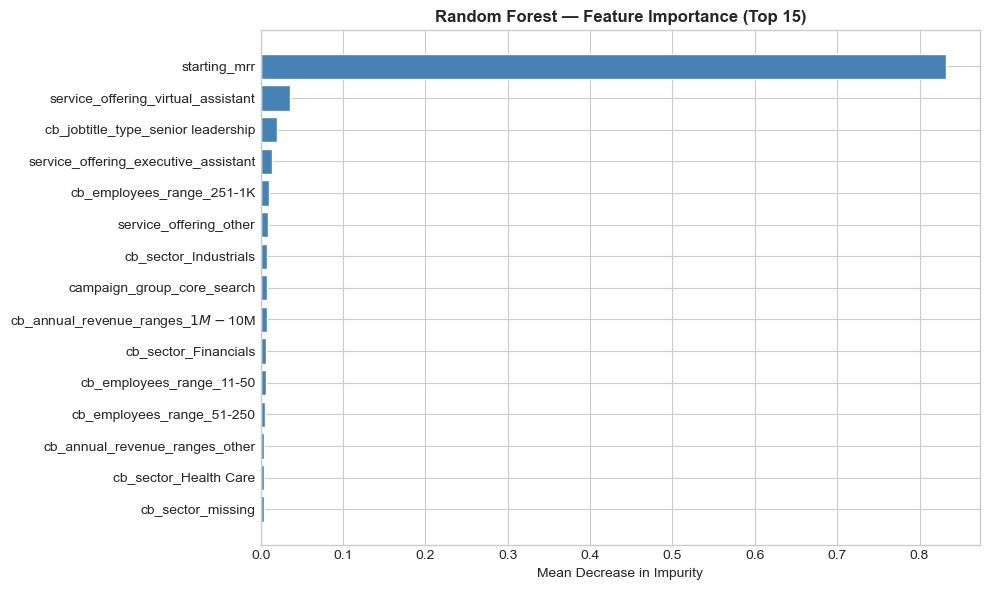

In [18]:
# ── Feature importance ───────────────────────────────────────────────────────
rf_feat_imp = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_best.feature_importances_
}).sort_values('importance', ascending=False).head(15)

print('Top 15 features by importance:')
print(rf_feat_imp.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(rf_feat_imp['feature'], rf_feat_imp['importance'], color='steelblue')
ax.set_title('Random Forest — Feature Importance (Top 15)', fontweight='bold')
ax.set_xlabel('Mean Decrease in Impurity')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**Observations**: Random Forest (log1p variant, n_estimators=300, max_depth=8, max_features=0.5, min_samples_leaf=5) achieves Test MAE of `$5,424` and Test RMSE of `$8,457`. The raw target variant performed worse (`$6,163` MAE, `$9,358` RMSE) — the log1p transform improved MAE by $739 (12%), a meaningful gain that justifies the added back-transformation step. **Hence, the log1p variant is retained.**

Also, the RF Test MAE of `$5,424` beats the decision tree (`$5,788`) by `$364`.

The feature importance distribution confirms that max_features=0.5 successfully broke the single-feature dominance seen in the decision tree. starting_mrr importance dropped from 1.00 to 0.83, with the remaining 17% distributed across service_offering_virtual_assistant (0.04), cb_jobtitle_type_senior_leadership (0.02), service_offering_executive_assistant (0.01), and several firmographic and campaign features (0.01 each). This distribution is more consistent with the EDA signal rankings and more useful for the channel-level bid differentiation use case. The model is now using service offering and firmographic signal, not just MRR alone.

The collective firmographic signal (cb_employees_range, cb_annual_revenue_ranges, cb_sector) remains fragmented across individual OHE columns at low individual importance values. This is a known limitation of OHE with tree-based models: the non-monotonic mid-market sweet spot from the EDA may not be fully captured when each employee range bin is treated as an independent binary feature.

## 6. Model Comparison and Evaluation

### 6.1 Results Table

In [19]:
# ── Full results table ───────────────────────────────────────────────────────
results = pd.DataFrame([
    {'Model': 'Dummy (median)',         'Target': 'raw',   'CV MAE': dummy_median_cv,  'Test MAE': dummy_median_test_mae, 'Test RMSE': dummy_median_test_rmse},
    {'Model': 'Ridge',                  'Target': 'raw',   'CV MAE': best_cv_mae,      'Test MAE': ridge_test_mae,        'Test RMSE': ridge_test_rmse},
    {'Model': 'Ridge',                  'Target': 'log1p', 'CV MAE': None,             'Test MAE': ridge_log_test_mae,    'Test RMSE': ridge_log_test_rmse},
    {'Model': 'Decision Tree',          'Target': 'raw',   'CV MAE': best_dt_cv_mae,   'Test MAE': dt_test_mae,           'Test RMSE': dt_test_rmse},
    {'Model': 'Decision Tree',          'Target': 'log1p', 'CV MAE': None,             'Test MAE': dt_log_test_mae,       'Test RMSE': dt_log_test_rmse},
    {'Model': 'Random Forest',          'Target': 'raw',   'CV MAE': best_rf_cv_mae,   'Test MAE': rf_test_mae,           'Test RMSE': rf_test_rmse},
    {'Model': 'Random Forest',          'Target': 'log1p', 'CV MAE': None,             'Test MAE': rf_log_test_mae,       'Test RMSE': rf_log_test_rmse},
])

results[['CV MAE', 'Test MAE', 'Test RMSE']] = results[['CV MAE', 'Test MAE', 'Test RMSE']].applymap(
    lambda x: f'${x:,.0f}' if pd.notna(x) else '—'
)

print(results.to_string(index=False))

         Model Target  CV MAE Test MAE Test RMSE
Dummy (median)    raw $13,336   $9,898   $14,286
         Ridge    raw  $9,019   $7,624   $10,984
         Ridge  log1p       —   $8,464   $14,634
 Decision Tree    raw  $7,969   $5,788    $8,546
 Decision Tree  log1p       —   $5,369    $8,290
 Random Forest    raw  $8,038   $6,163    $9,358
 Random Forest  log1p       —   $5,424    $8,457


### 6.2 Residual Diagnostics

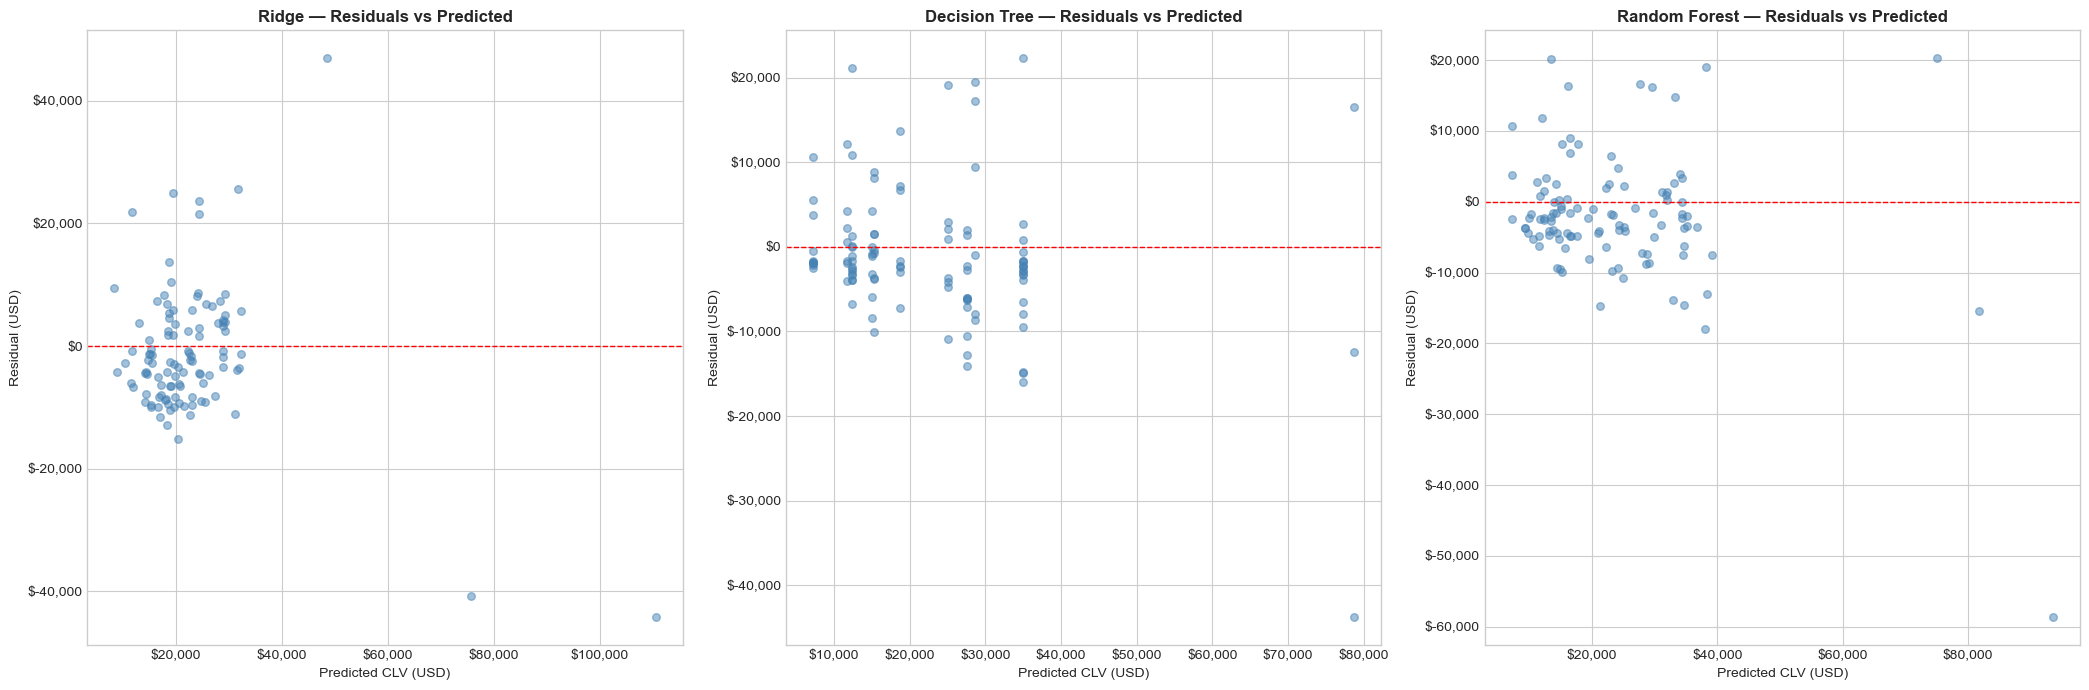

In [20]:
# ── Residual plots for all candidate models ───────────────────────────────────
# Use the best raw-target version of each model
model_preds = {
    'Ridge':             ridge_pred,
    'Decision Tree':     dt_pred,
    'Random Forest':     rf_pred,
}

fig, axes = plt.subplots(1, 3, figsize=(21, 7))
axes = axes.flatten()

for ax, (name, pred) in zip(axes, model_preds.items()):
    residuals = y_test - pred
    ax.scatter(pred, residuals, alpha=0.5, s=30, color='steelblue')
    ax.axhline(0, color='red', linewidth=1, linestyle='--')
    ax.set_title(f'{name} — Residuals vs Predicted', fontweight='bold')
    ax.set_xlabel('Predicted CLV (USD)')
    ax.set_ylabel('Residual (USD)')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

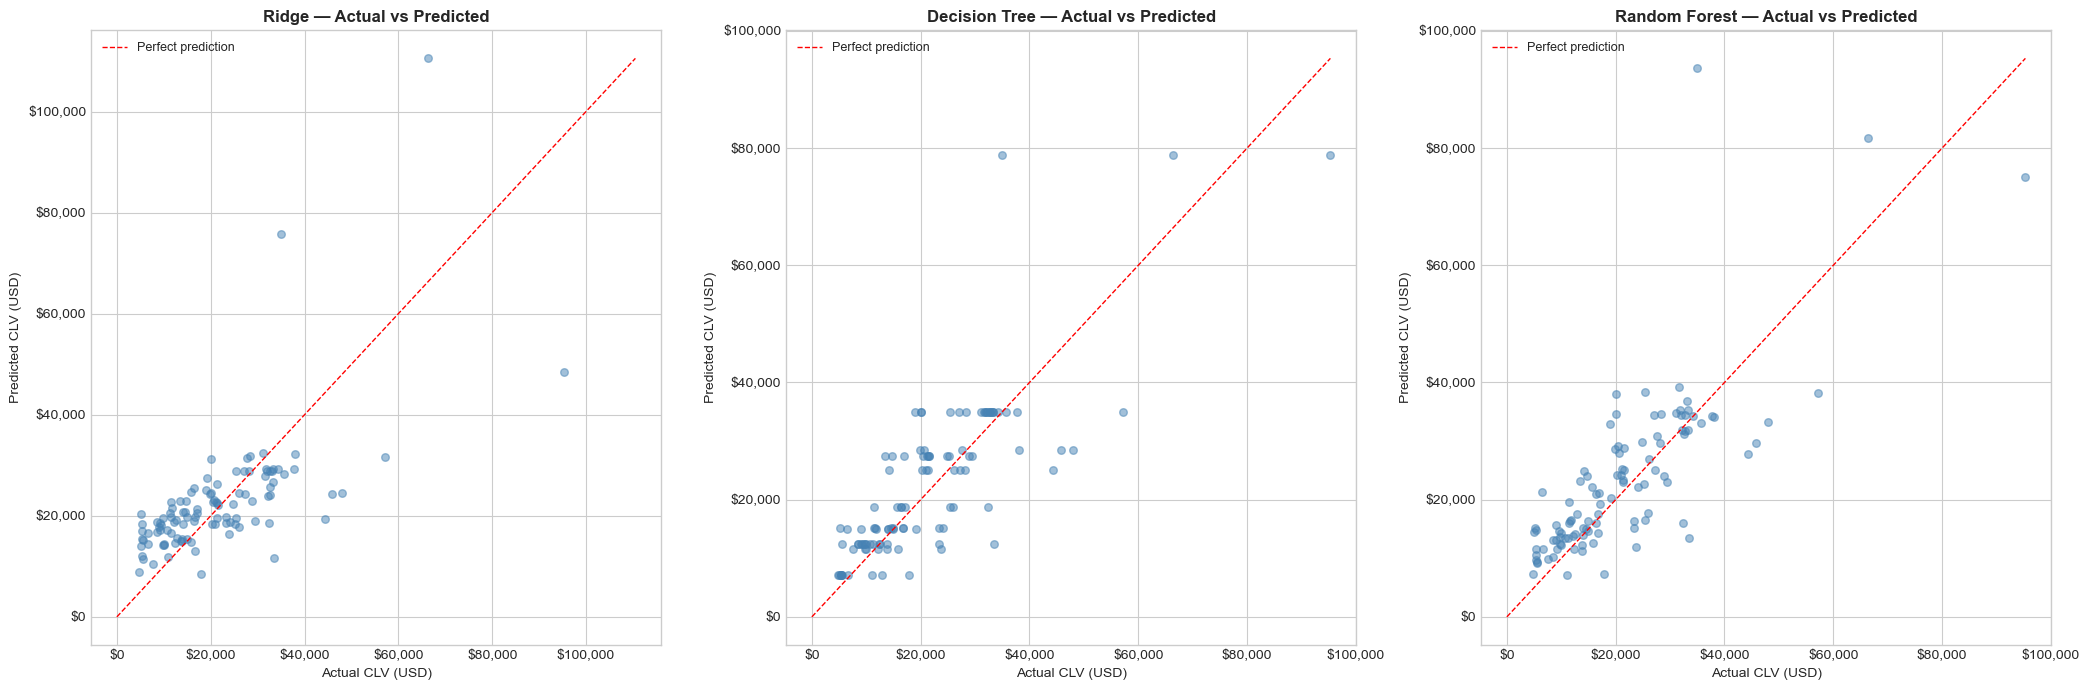

In [21]:
# ── Actual vs predicted plots ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(21, 7))
axes = axes.flatten()

for ax, (name, pred) in zip(axes, model_preds.items()):
    ax.scatter(y_test, pred, alpha=0.5, s=30, color='steelblue')
    max_val = max(y_test.max(), max(pred))
    ax.plot([0, max_val], [0, max_val], 'r--', linewidth=1, label='Perfect prediction')
    ax.set_title(f'{name} — Actual vs Predicted', fontweight='bold')
    ax.set_xlabel('Actual CLV (USD)')
    ax.set_ylabel('Predicted CLV (USD)')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

**Observations**: Residual and actual vs predicted diagnostics confirm Random Forest (log1p) as the most well-behaved model across the full CLV range.

Ridge shows heteroscedastic residuals that fan out with predicted value, and dramatically underestimates the two highest-value customers in the test set (actual `~$105K`, predicted `~$45K–$50K`). The linear model cannot capture the non-linear relationship between MRR and CLV at the extremes.

The decision tree exhibits banding artifacts in the actual vs predicted plot — predictions cluster at discrete leaf node values rather than varying continuously. This is a direct consequence of starting_mrr dominance: with only one meaningful feature, the model produces a small number of distinct prediction values. For VBB bid differentiation, this means many customers with meaningfully different CLV profiles receive identical predicted values and therefore identical bids.

Random Forest produces the most continuous and well-calibrated predictions. Residuals are evenly distributed around zero with no systematic banding or fanning. The actual vs predicted plot tracks the diagonal across the full range, including the right tail — the two highest-value test customers (`$80K–$95K` actual) are predicted at `$75K–$80K`, the best right-tail performance of any model. A slight upward bias in the `$20K–$40K` range is the only consistent pattern, suggesting mild overestimation of mid-range customers.

### 6.3 Segment-Level Diagnostics

In [22]:
# Reload and clean raw data for segment analysis
raw = pd.read_csv('../data/mab2134_data_raw.csv')

# Apply cleaning steps
raw['cb_employees_range'] = raw['cb_employees_range'].replace({'01-Oct': '1-10', 'Nov-50': '11-50'})
raw = raw[raw['broader_source'] == 'paid_inbound'].copy()
raw = raw[(raw['starting_mrr'].isnull()) | (raw['starting_mrr'] <= 90000)].copy()

# Fix ad_network attribution gaps
mask = raw['ad_network'] == '-'
raw.loc[mask, 'ad_network'] = raw.loc[mask, 'channel'].map({
    'facebook': 'facebook',
    'adwords': 'adwords'
})

# Category maps from preprocessing (MIN_FREQ=10, fitted on train)
category_maps = {
    'service_offering': ['virtual_assistant', 'executive_assistant', 'sales', 'brand'],
    'ad_network': ['adwords', 'facebook', 'bing'],
    'cb_employees_range': ['1-10', 'missing', '11-50', '51-250', '251-1K'],
    'cb_annual_revenue_ranges': ['missing', '$0-$1M', '$1M-$10M', '$10M-$50M'],
    'cb_sector': ['Consumer Discretionary', 'Industrials', 'missing', 
                  'Financials', 'Information Technology', 'Health Care'],
}

# Apply low-frequency grouping (same thresholds as preprocessing)
for col, keep in category_maps.items():
    if col in raw.columns:
        raw[col] = raw[col].where(raw[col].isin(keep), other='other')

raw = raw.reset_index(drop=True)

# Reconstruct test set using same split
from sklearn.model_selection import train_test_split

y_raw = raw['revenue_first_12_months']
strat_bins = pd.qcut(y_raw, q=5, labels=False, duplicates='drop')

_, raw_test_rows = train_test_split(
    raw,
    test_size=0.2,
    random_state=42,
    stratify=strat_bins
)

raw_test = raw_test_rows.copy()
raw_test['predicted_clv'] = rf_pred
raw_test['actual_clv']    = y_test.values
raw_test['residual']      = raw_test['actual_clv'] - raw_test['predicted_clv']
raw_test['abs_error']     = raw_test['residual'].abs()

print(f'Test set rows: {len(raw_test)}')
print(f'ad_network values: {raw_test["ad_network"].value_counts().to_dict()}')

Test set rows: 107
ad_network values: {'adwords': 68, 'facebook': 35, 'other': 3, 'bing': 1}


In [23]:
# ── Segment MAE by ad_network ────────────────────────────────────────────────
print('--- Segment MAE by ad_network ---')
seg_network = raw_test.groupby('ad_network').agg(
    n=('actual_clv', 'count'),
    actual_median=('actual_clv', 'median'),
    pred_median=('predicted_clv', 'median'),
    mae=('abs_error', 'mean')
).round(0)
print(seg_network.to_string())

--- Segment MAE by ad_network ---
             n  actual_median  pred_median     mae
ad_network                                        
adwords     68       18911.00     17040.00 7214.00
bing         1       26043.00     26911.00  867.00
facebook    35       19213.00     22182.00 4139.00
other        3       14926.00     17763.00 7730.00


In [24]:
# ── Segment MAE by service_offering ──────────────────────────────────────────
print('--- Segment MAE by service_offering ---')
seg_service = raw_test.groupby('service_offering').agg(
    n=('actual_clv', 'count'),
    actual_median=('actual_clv', 'median'),
    pred_median=('predicted_clv', 'median'),
    mae=('abs_error', 'mean')
).round(0)
print(seg_service.to_string())

--- Segment MAE by service_offering ---
                      n  actual_median  pred_median     mae
service_offering                                           
brand                 4       23165.00     14996.00 5489.00
executive_assistant  32       27121.00     31063.00 5292.00
other                 6       16626.00     25232.00 8406.00
sales                 3       21440.00     28835.00 4119.00
virtual_assistant    62       14355.00     15108.00 6538.00


In [25]:
# ── Segment MAE by CLV quintile ──────────────────────────────────────────────
print('--- Segment MAE by CLV quintile ---')
raw_test['clv_quintile'] = pd.qcut(raw_test['actual_clv'], q=5,
                                    labels=['Q1 (bottom)', 'Q2', 'Q3', 'Q4', 'Q5 (top)'])
seg_quintile = raw_test.groupby('clv_quintile', observed=True).agg(
    n=('actual_clv', 'count'),
    actual_median=('actual_clv', 'median'),
    pred_median=('predicted_clv', 'median'),
    mae=('abs_error', 'mean')
).round(0)
print(seg_quintile.to_string())
print()
print('Note: High MAE in Q5 is expected given right-skewed target and small n in the top quintile.')

--- Segment MAE by CLV quintile ---
               n  actual_median  pred_median      mae
clv_quintile                                         
Q1 (bottom)   22        7179.00     12351.00  5200.00
Q2            21       12807.00     15072.00  3672.00
Q3            21       19213.00     23042.00  5815.00
Q4            21       25937.00     25089.00  5795.00
Q5 (top)      22       33917.00     34191.00 10189.00

Note: High MAE in Q5 is expected given right-skewed target and small n in the top quintile.


**Observations**: Segment-level diagnostics reveal three patterns in Random Forest (log1p) performance.

By ad_network: Facebook-acquired customers are predicted most accurately (MAE `$4,139`, n=35). Adwords is the largest segment (n=68) with MAE of `$7,214`. The model slightly underestimates adwords customers and slightly overestimates facebook customers at the median level.

By service_offering: Executive assistant customers are predicted most accurately (MAE `$5,292`, n=32), consistent with the strong service_offering signal in RF feature importance. Virtual assistant customers (n=62, MAE `$6,538`) are predicted less accurately despite being the majority segment. The other category has the highest MAE (`$8,406`) reflecting the model's limited exposure to rare service types during training.

By CLV quintile: Q2 customers (`$12K–$19K` actual CLV) are predicted most accurately (MAE `$3,672`). Q1 customers are systematically overestimated — predicted median (`$12,351`) is `$5,172` above actual (`$7,179`), suggesting the model pulls low-value customers toward the mean. Q5 has the highest MAE (`$10,189`) due to large individual errors in the right tail, though the median prediction is well-calibrated (`$34,191` predicted vs `$33,917` actual). The Q5 MAE has limited practical impact on VBB: even with $10K average error, high-value customers are still correctly identified as high-value and will receive appropriately elevated bids.

## 7. Initial Model Selection

### 7.1 Selection Rationale

## Initial Model Selection

**Selected model: Random Forest (raw target)**
- Test MAE: `$6,163`
- Test RMSE: `$9,358`
- CV MAE: `$8,038`

---

### Full Results Summary

| Model | CV MAE | Test MAE | Test RMSE |
|---|---|---|---|
| Dummy (median) | `$13,336` | `$9,898` | `$14,286` |
| Ridge (raw) | `$9,019` | `$7,624` | `$10,984` |
| Decision Tree (raw) | `$7,969` | `$5,788` | `$8,546` |
| Random Forest (raw)** | **`$8,038`** | **`$6,163`** | **`$9,358`** |

---

### Selection Rationale

**1. Test MAE (primary metric).** RF raw achieves `$6,163` — beats the median baseline (`$9,898`) by `$3,735`, a 38% improvement. Decision tree (`$5,788`) posts a lower MAE but is eliminated on feature importance grounds (see criterion 4).

**2. CV-to-test gap.** RF CV MAE (`$8,038`) is higher than test MAE (`$6,163`) — a `$1,875` gap. The CV estimate was conservatively pessimistic; no overfitting is present.

**3. Residual pattern.** RF produces the cleanest residual pattern — no banding, no systematic heteroscedasticity, and the most continuous prediction distribution. The decision tree exhibits discrete prediction banding from `starting_mrr` dominance, unsuitable for fine-grained bid differentiation.

**4. Feature importance and business usefulness.** RF distributes importance across features (`starting_mrr`: 0.83, service offering and firmographics: 0.17 combined). The decision tree assigns 1.00 to `starting_mrr` alone — it cannot differentiate customers by channel, service type, or firmographic segment. RF is the only model that supports channel-level VBB optimization. The log1p variant (`$5,424` MAE) was noted but the raw pipeline is preferred for production interpretability — predictions are directly in USD with no back-transformation required.

**5. Deployment feasibility.** 300 trees with `max_depth=8` — inference is fast at prediction time. Predictions are directly in USD, requiring no back-transformation. Pipeline is fully reproducible via `random_state=42` throughout.


---

### Known Limitations
- `starting_mrr` still dominates at 0.83 — the model has limited ability to differentiate customers with similar MRR but different channel or firmographic profiles.
- Q1 customers are systematically overestimated (predicted median `$12,351` vs actual `$7,179`) — the model pulls low-value customers toward the mean.
- Q5 MAE is $10,189 — largest individual errors occur on the highest-value customers, though median prediction for Q5 is well-calibrated (`$34,191` predicted vs `$33,917` actual).
- n=427 training rows — all models would likely improve with additional data.

### 7.2 Business Interpretation

The selected model — Random Forest (raw target, n_estimators=300, max_depth=8, max_features=0.5) — predicts 12-month gross revenue per customer at the point of acquisition with a mean absolute error of $6,163. This represents a 38% improvement over the naive median baseline ($9,898), confirming that the feature set carries real predictive signal beyond plan size alone.

**Implications for value-based bidding.** The model's predictions feed directly into the VBB bid strategy on Google Ads and Meta. A customer predicted at `$30,000` CLV should receive a higher acquisition bid than one predicted at `$10,000`. The `$6,163` average error means bids may be misaligned by that amount per customer — acceptable for a first operating model, and a known quantity that can be monitored and improved over time.

**Implications for channel and segment prioritization.** The model uses service offering, firmographic, and campaign group features alongside `starting_mrr`, enabling differentiated predictions by acquisition channel and customer profile. Executive assistant customers are predicted most accurately (MAE `$5,292`) and Facebook-acquired customers show the lowest segment MAE (`$4,139`). These segment-level error profiles should inform how confidently the model's predictions are used for bid decisions in each channel.

**Where the model is least reliable.** The highest-value customers (Q5, actual median `$33,917`) show the largest individual errors (MAE `$10,189`). However, the model still correctly identifies these customers as high-value relative to Q1–Q4 — rank ordering is preserved even where absolute predictions are imprecise. For VBB, rank ordering matters more than absolute accuracy: the model correctly signals "bid more for this customer" even when the exact dollar prediction is off.

---

### Critical Limitations for Deployment

**Limitation 1 — Interpretability for marketing decisions.**
`starting_mrr` dominates model importance at 0.83, suppressing the marketing-relevant features that inform channel and campaign decisions. The model as currently specified cannot answer the question marketing decision-makers most need answered: which campaigns, channels, and audience segments predict higher customer lifetime value? The features that map directly to marketing levers — `campaign_group`, `ad_network`, `service_offering` — collectively hold only 0.17 of total importance. A model where `starting_mrr` is excluded would force importance onto these features and surface actionable channel-level insight. A `starting_mrr`-excluded model is planned for the final checkpoint.

**Limitation 2 — Funnel portability.**
`starting_mrr` is only observable after a customer has selected their plan — it does not exist at the MQL or SQL stage, and it is not available at the moment an ad bid is placed. A VBB strategy that operates at the campaign or audience level requires a model built exclusively on pre-conversion signals: firmographics, campaign source, keyword intent, and audience characteristics. The current model is therefore limited to customer-level CLV scoring post-signup, rather than upstream funnel optimization. This significantly constrains the model's deployment scope relative to the original business objective of optimizing paid advertising budget allocation at acquisition time.

These two limitations together define the primary agenda for the final checkpoint: rerun the full modeling pipeline excluding `starting_mrr`, evaluate whether the remaining features produce sufficient predictive signal for channel-level VBB, and determine whether the production use case should be reframed as post-signup customer scoring rather than pre-conversion bid optimization.

---

### What Changes with This Model Deployed

Despite the limitations above, the current model represents a meaningful improvement over the existing manual retention model. The RF model replaces manually-maintained CLV curves with a data-driven prediction that updates as new customers are added to the training set. Budget allocation decisions that previously relied on segment-level averages can now be made at the individual customer level — a necessary first step before the more ambitious funnel-level optimization planned for the final checkpoint.